In [3]:
!pip install sentence-transformers
import os
# Disable the warning message
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1' 
# Disable the token warning
os.environ['HF_TOKEN'] = '' 

import warnings
warnings.filterwarnings("ignore", message=".*unauthenticated requests.*")

Defaulting to user installation because normal site-packages is not writeable


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Analyzing Semantic Similarity (SBERT)...
Cosine Similarity Matrix (Task 3e Analysis):
 [[1.     0.9868 0.8794 0.3006]
 [0.9868 1.     0.8628 0.2872]
 [0.8794 0.8628 1.     0.3164]
 [0.3006 0.2872 0.3164 1.    ]]


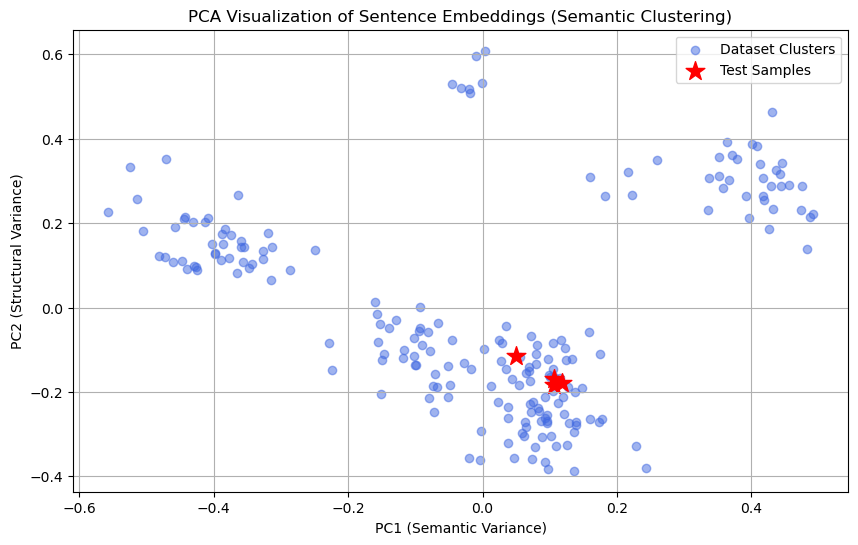

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

# Load the transformer model (Satisfies Task 3a: Language Model Embeddings)
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')

# 1. Define Comparison Samples (Focusing on spatial logic and domain variation)
samples = [
    "a small red circle is above a large blue square",
    "a small red circle is below a large blue square", # Spatial change
    "a small green circle is above a large blue square", # Attribute change
    "X marks the top-left, O marks the center"         # Domain change (Tic-Tac-Toe)
]

# 2. Generate Sentence Embeddings
sbert_embeddings = sbert_model.encode(samples)

# 3. Comparative Analysis: Similarity Matrix
print("Analyzing Semantic Similarity (SBERT)...")
sim_matrix = cosine_similarity(sbert_embeddings)

# Hypothesis: SBERT distinguishes logic changes while maintaining semantic proximity.
print("Cosine Similarity Matrix (Task 3e Analysis):\n", np.round(sim_matrix, 4))

# 4. Visualization: PCA Analysis (Task 3d)
# Load full dataset for clustering visualization
df_shapes = pd.read_csv('sentence_dataset_shapes.csv')
full_data_samples = df_shapes['sentence'].head(200).tolist()
embeddings_viz = sbert_model.encode(full_data_samples)

pca = PCA(n_components=2)
coords = pca.fit_transform(embeddings_viz)

plt.figure(figsize=(10, 6))
plt.scatter(coords[:, 0], coords[:, 1], c='royalblue', alpha=0.5, label='Dataset Clusters')

# Highlight our specific experiment samples
sample_coords = pca.transform(sbert_embeddings)
plt.scatter(sample_coords[:, 0], sample_coords[:, 1], c='red', marker='*', s=200, label='Test Samples')

plt.title("PCA Visualization of Sentence Embeddings (Semantic Clustering)")
plt.xlabel("PC1 (Semantic Variance)")
plt.ylabel("PC2 (Structural Variance)")
plt.legend()
plt.grid(True)
plt.show()